##### Import the libraries


In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import holidays
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

##### Load the Feature-Engineered Dataset

In [161]:
df = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\Model_Dataset\Hospital_Bed_Demand_Feature_Engineered.csv")
df.head()

,hospital_id,datetime,ward,occupied_beds,staffed_beds,occupancy_rate,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7,day_of_week,month,quarter,week_of_year,is_weekend,is_public_holiday,avg_los,median_los,max_los
0,HHN-BIR-01,2024-01-08,ICU,8.916667,8.916667,1.000000,8.958333,6.291667,2.041667,6.261905,1.903444,0,1,1,2,0,0,60.633333,60.90,66.1
1,HHN-BIR-01,2024-01-09,ICU,8.916667,8.916667,1.000000,8.916667,8.958333,4.583333,6.880952,1.970034,1,1,1,2,0,0,23.100000,23.10,23.1
2,HHN-BIR-01,2024-01-10,ICU,8.791667,8.791667,1.000000,8.916667,8.916667,4.916667,7.434524,1.867866,2,1,1,2,0,0,72.250000,72.25,77.2
3,HHN-BIR-01,2024-01-11,ICU,8.791667,8.958333,0.981481,8.791667,8.916667,5.000000,7.976190,1.570278,3,1,1,2,0,0,207.250000,207.25,338.4
4,HHN-BIR-01,2024-01-12,ICU,8.875000,8.875000,1.000000,8.791667,8.791667,5.166667,8.505952,0.978480,4,1,1,2,0,0,95.040000,98.50,176.3


In [162]:
df["ward"].unique()

array(['ICU', 'Cardiology Ward', 'Oncology Ward', 'Day Case Unit',
       'General Medicine Ward A', 'General Medicine Ward B',
       'Orthopaedics Ward A', 'Orthopaedics Ward B'], dtype=object)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28960 entries, 0 to 28959
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hospital_id        28960 non-null  object 
 1   datetime           28960 non-null  object 
 2   ward               28960 non-null  object 
 3   occupied_beds      28960 non-null  float64
 4   staffed_beds       28960 non-null  float64
 5   occupancy_rate     28960 non-null  float64
 6   lag_1              28960 non-null  float64
 7   lag_2              28960 non-null  float64
 8   lag_7              28960 non-null  float64
 9   rolling_mean_7     28960 non-null  float64
 10  rolling_std_7      28960 non-null  float64
 11  day_of_week        28960 non-null  int64  
 12  month              28960 non-null  int64  
 13  quarter            28960 non-null  int64  
 14  week_of_year       28960 non-null  int64  
 15  is_weekend         28960 non-null  int64  
 16  is_public_holiday  289

##### Create the Unit Identifier

In [164]:
# Create one identifier for each hospital ward
df["unit_id"] = (df["hospital_id"] + "_" + df["ward"])

df["unit_id"].unique()

array(['HHN-BIR-01_ICU', 'HHN-EDI-01_ICU', 'HHN-LON-01_ICU',
       'HHN-LON-02_ICU', 'HHN-MAN-01_ICU', 'HHN-BIR-01_Cardiology Ward',
       'HHN-EDI-01_Cardiology Ward', 'HHN-LON-01_Cardiology Ward',
       'HHN-LON-02_Cardiology Ward', 'HHN-MAN-01_Cardiology Ward',
       'HHN-BIR-01_Oncology Ward', 'HHN-EDI-01_Oncology Ward',
       'HHN-LON-01_Oncology Ward', 'HHN-LON-02_Oncology Ward',
       'HHN-MAN-01_Oncology Ward', 'HHN-BIR-01_Day Case Unit',
       'HHN-EDI-01_Day Case Unit', 'HHN-LON-01_Day Case Unit',
       'HHN-LON-02_Day Case Unit', 'HHN-MAN-01_Day Case Unit',
       'HHN-BIR-01_General Medicine Ward A',
       'HHN-EDI-01_General Medicine Ward A',
       'HHN-LON-01_General Medicine Ward A',
       'HHN-LON-02_General Medicine Ward A',
       'HHN-MAN-01_General Medicine Ward A',
       'HHN-BIR-01_General Medicine Ward B',
       'HHN-EDI-01_General Medicine Ward B',
       'HHN-LON-01_General Medicine Ward B',
       'HHN-LON-02_General Medicine Ward B',
       'HHN-

##### Naive Forest (yesterday's occupancy)

In [165]:
# Store results as a list
naive_results = []

# Initialize list to store predictions
naive_predictions = []

for unit in df["unit_id"].unique():

    # Select one ward
    df_unit = df[df["unit_id"] == unit].copy()

    # Sort by date
    df_unit = df_unit.sort_values("datetime")

    # Target variable
    y = df_unit["occupied_beds"]

    # Train/Test Split (last 7 days)
    train = y[:-7]
    test = y[-7:]

    # Naive Forecast
    last_value = train.iloc[-1]
    prediction = np.repeat(last_value, len(test))

    # Apply physical capacity constraints (using staffed beds from the test period)
    max_capacity = df_unit.iloc[-7:]["staffed_beds"].max()
    prediction = np.clip(prediction, 0, max_capacity)

    # Evaluation metrics
    mae = mean_absolute_error(test, prediction)
    rmse = np.sqrt(mean_squared_error(test, prediction))
    mape = mean_absolute_percentage_error(test, prediction)

    # Save results
    naive_results.append({"Unit": unit, "MAE": mae, "RMSE": rmse, "MAPE": mape})

    # Create and save predictions DataFrame for this unit
    pred_df = pd.DataFrame({
            "Unit": unit,
            "Date": df_unit.iloc[-7:]["datetime"].values,
            "Actual": test.values,
            "Predicted": prediction,
        })
    naive_predictions.append(pred_df)


# Convert results to DataFrame AFTER the loop
naive_results = pd.DataFrame(naive_results)

# Sort by best MAE
naive_results = naive_results.sort_values("MAE")

# --- SAVING OPERATIONAL ARTIFACTS ---

# Save evaluation summary metrics
naive_results.to_csv("../Models/Baseline Models/Results/naive_forcasts.csv", index=False)

# Combine and save all predictions
naive_predictions = pd.concat(naive_predictions, ignore_index=True)
naive_predictions.to_csv("../Models/Baseline Models/Predictions/naive_predictions.csv", index=False)

# Display results table
naive_results

,Unit,MAE,RMSE,MAPE
30,HHN-BIR-01_Orthopaedics Ward A,0.041667,0.084808,3.863240e-03
8,HHN-LON-02_Cardiology Ward,0.065476,0.093169,3.691322e-03
31,HHN-EDI-01_Orthopaedics Ward A,0.083333,0.097080,8.459466e-03
20,HHN-BIR-01_General Medicine Ward A,0.101190,0.110240,6.382476e-03
21,HHN-EDI-01_General Medicine Ward A,0.107143,0.117851,6.391572e-03
15,HHN-BIR-01_Day Case Unit,0.130952,0.172516,2.680714e+14
23,HHN-LON-02_General Medicine Ward A,0.136905,0.165921,7.728103e-03
36,HHN-EDI-01_Orthopaedics Ward B,0.160714,0.181621,1.640055e-02
33,HHN-LON-02_Orthopaedics Ward A,0.220238,0.323133,1.928841e-02
4,HHN-MAN-01_ICU,0.238095,0.367990,2.539981e-02


    The **Naive Forecast model** performed well for stable wards such as **Orthopaedics, Cardiology, and General Medicine**, achieving low prediction errors. However, it struggled with more unpredictable wards, particularly **Oncology and some Cardiology units**, where demand changes frequently.



##### Moving Average Forecast (average of the previous 7 days)

In [166]:
# Store results here
moving_average_results = []

# Initialize list to collect historical test predictions
moving_average_predictions = []

# Loop through every hospital ward
for unit in df["unit_id"].unique():

    # Select one unit
    df_unit = df[df["unit_id"] == unit].sort_values("datetime").copy()

    # Train/Test Split (last 7 days for testing)
    train = df_unit.iloc[:-7]
    test = df_unit.iloc[-7:]

    # Moving Average Forecast (7-day average)
    moving_avg = train["occupied_beds"].rolling(window=7).mean().iloc[-1]

    # Predict same value for the next 7 days
    predictions = np.repeat(moving_avg, len(test))

    # Apply physical capacity constraints (using staffed beds from the test period)
    max_capacity = test["staffed_beds"].max()
    predictions = np.clip(predictions, 0, max_capacity)

    # Evaluation Metrics
    mae = mean_absolute_error(test["occupied_beds"], predictions)
    rmse = np.sqrt(mean_squared_error(test["occupied_beds"], predictions))
    mape = mean_absolute_percentage_error(test["occupied_beds"], predictions)

    # Save results
    moving_average_results.append({"Unit": unit, "MAE": mae, "RMSE": rmse, "MAPE": mape})

    # Construct and append the prediction DataFrame for this unit
    pred_df = pd.DataFrame({
            "Unit": unit,
            "Date": test["datetime"].values,
            "Actual": test["occupied_beds"].values,
            "Predicted": predictions,
        })
    moving_average_predictions.append(pred_df)

# AFTER the loop finishes, convert to DataFrame
moving_average_results = pd.DataFrame(moving_average_results)

# Sort by best MAE
moving_average_results = moving_average_results.sort_values("MAE")

# --- SAVING OPERATIONAL ARTIFACTS ---

# Save evaluation summary metrics
moving_average_results.to_csv("../Models/Baseline Models/Results/moving_average_results.csv", index=False)

# Combine and save all predictions
moving_average_predictions = pd.concat(moving_average_predictions, ignore_index=True)
moving_average_predictions.to_csv("../Models/Baseline Models/Predictions/moving_average_predictions.csv", index=False,)

# Display results
moving_average_results

,Unit,MAE,RMSE,MAPE
8,HHN-LON-02_Cardiology Ward,0.068027,0.089087,3.830673e-03
31,HHN-EDI-01_Orthopaedics Ward A,0.069728,0.088688,7.018746e-03
30,HHN-BIR-01_Orthopaedics Ward A,0.077381,0.084808,7.092960e-03
23,HHN-LON-02_General Medicine Ward A,0.079082,0.093927,4.452019e-03
16,HHN-EDI-01_Day Case Unit,0.199830,0.237275,1.532556e+00
28,HHN-LON-02_General Medicine Ward B,0.202381,0.222718,1.131777e-02
17,HHN-LON-01_Day Case Unit,0.214286,0.263523,2.680714e+14
15,HHN-BIR-01_Day Case Unit,0.216837,0.234572,4.442326e+14
18,HHN-LON-02_Day Case Unit,0.219388,0.240612,3.829592e+14
33,HHN-LON-02_Orthopaedics Ward A,0.225340,0.329646,1.973739e-02


    The **Moving Average model** performed well for wards with stable occupancy patterns, achieving very low errors in **London 2 Cardiology, Edinburgh Orthopaedics Ward A, Birmingham Orthopaedics Ward A, and London 2 General Medicine Ward A**. 
    However, performance was weaker in more unpredictable wards, especially **Oncology, some Cardiology, and General Medicine units**, where occupancy changes frequently. The high MAPE values in some Day Case Units were caused by very low or zero occupancy periods, making MAPE less reliable.


##### Holt-Winters (Trend, Weekly seasonality and Changes in occupancy over time)

In [167]:
# Store the results here
holt_results = []

# Initialize list to collect historical test predictions
holt_predictions = []

# Loop through every hospital ward
for unit in df["unit_id"].unique():

    # Select one unit
    df_unit = df[df["unit_id"] == unit].sort_values("datetime").copy()

    # Train/Test split (last 7 days)
    train = df_unit.iloc[:-7]
    test = df_unit.iloc[-7:]

    # Fit the Holt-Winters model
    model = ExponentialSmoothing(train["occupied_beds"], trend="add", seasonal="add", seasonal_periods=7)
    fitted_model = model.fit()

    # Forecast
    predictions = fitted_model.forecast(7)

    # Apply physical capacity constraints (using staffed beds from the test period)
    max_capacity = test["staffed_beds"].max()
    predictions = np.clip(predictions, 0, max_capacity)

    # Evaluation Metrics
    mae = mean_absolute_error(test["occupied_beds"], predictions)
    rmse = np.sqrt(mean_squared_error(test["occupied_beds"], predictions))
    mape = mean_absolute_percentage_error(test["occupied_beds"], predictions)

    # Save the results
    holt_results.append({"Unit": unit, "MAE": mae, "RMSE": rmse, "MAPE": mape})

    # Construct and append the prediction DataFrame for this unit
    pred_df = pd.DataFrame({
            "Unit": unit,
            "Date": test["datetime"].values,
            "Actual": test["occupied_beds"].values,
            "Predicted": predictions.values,
        })
    holt_predictions.append(pred_df)

    # Save this hospital's model
    joblib.dump(fitted_model, f"../Models/Baseline Models/Trained Models/Holt/holt_{unit}.pkl",)

# AFTER the loop finishes, convert to DataFrame
holt_results = pd.DataFrame(holt_results)

# Sort by best MAE
holt_results = holt_results.sort_values("MAE")

# --- SAVING OPERATIONAL ARTIFACTS ---

# Save evaluation summary metrics
holt_results.to_csv("../Models/Baseline Models/Results/holt_results.csv", index=False)

# Combine and save all predictions
# Save predictions cleanly alongside your other baselines
holt_predictions = pd.concat(holt_predictions, ignore_index=True)
holt_predictions.to_csv("../Models/Baseline Models/Predictions/holt_predictions.csv", index=False)

# Display results
holt_results

,Unit,MAE,RMSE,MAPE
30,HHN-BIR-01_Orthopaedics Ward A,0.085957,0.126234,7.898611e-03
23,HHN-LON-02_General Medicine Ward A,0.149556,0.200664,8.425995e-03
21,HHN-EDI-01_General Medicine Ward A,0.162327,0.183607,9.696128e-03
16,HHN-EDI-01_Day Case Unit,0.190554,0.229388,7.591186e-01
4,HHN-MAN-01_ICU,0.204275,0.359772,2.194544e-02
33,HHN-LON-02_Orthopaedics Ward A,0.205685,0.260527,1.768518e-02
20,HHN-BIR-01_General Medicine Ward A,0.216116,0.250543,1.365993e-02
18,HHN-LON-02_Day Case Unit,0.222797,0.252547,2.636237e+14
31,HHN-EDI-01_Orthopaedics Ward A,0.250631,0.353076,2.543974e-02
0,HHN-BIR-01_ICU,0.284338,0.487589,3.549822e-02


    The **Holt-Winters model** performed well for wards with stable demand patterns, achieving low forecasting errors in **Birmingham Orthopaedics Ward A, London 2 General Medicine Ward A, Edinburgh General Medicine Ward A, and Manchester ICU**. Many wards achieved errors below **1 bed**, showing that the model effectively captured trends and seasonal patterns.
    However, the model struggled with highly variable wards, particularly **London 1 Cardiology Ward and London 2 Oncology Ward**, which recorded the highest prediction errors due to unpredictable changes in patient demand. High MAPE values in some Day Case Units were caused by very low or zero occupancy levels, making percentage errors less reliable.


##### SARIMA

In [168]:
# Store the results here
sarima_results = []

# Initialize list to collect historical test predictions
sarima_predictions = []

# Loop through every hospital ward
for unit in df["unit_id"].unique():

    # Select one unit
    df_unit = df[df["unit_id"] == unit].sort_values("datetime").copy()

    # Train/Test split (last 7 days)
    train = df_unit.iloc[:-7]
    test = df_unit.iloc[-7:]

    # Define parameters based on clinical properties observed during EDA
    # Defaulting to a robust (2,0,0)x(1,0,1)7 to capture short-term memory and weekly rhythm
    p, d, q = 2, 0, 0
    P, D, Q, s = 1, 0, 1, 7

    # If it's one of the non-stationary drifting units identified in Phase 1, enforce differencing
    if "HHN-LON-01_General Medicine" in unit or "HHN-MAN-01_General Medicine" in unit:
        d, D = 1, 1

    try:
        # Fit the SARIMA model using Statsmodels SARIMAX implementation
        model = SARIMAX(
            train["occupied_beds"],
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fitted_model = model.fit(disp=False)

        # Forecast the next 7 days
        predictions = fitted_model.forecast(7)

        # Apply the physical constraint post-processing rule:
        # Bed demand cannot drop below 0 or exceed the ward's maximum staffed capacity
        max_capacity = df_unit["staffed_beds"].max()
        predictions = np.clip(predictions, 0, max_capacity)

        # Evaluation Metrics
        mae = mean_absolute_error(test["occupied_beds"], predictions)
        rmse = np.sqrt(mean_squared_error(test["occupied_beds"], predictions))
        mape = mean_absolute_percentage_error(test["occupied_beds"], predictions)

        # Save the results
        sarima_results.append(
            {"Unit": unit, "MAE": mae, "RMSE": rmse, "MAPE": mape}
        )

        #Construct and append the prediction DataFrame for this unit
        pred_df = pd.DataFrame(
            {
                "Unit": unit,
                "Date": test["datetime"].values,
                "Actual": test["occupied_beds"].values,
                "Predicted": predictions.values,
            }
        )
        sarima_predictions.append(pred_df)

        # FIX 3: Placed safely INSIDE the try block so it executes successfully
        joblib.dump(fitted_model, f"../Models/Baseline Models/Trained Models/Sarima/sarima_{unit}.pkl",)

    except Exception as e:
        # Fallback to prevent loop disruption if a specific matrix optimization fails
        print(f"Skipping optimization for {unit} due to error: {e}")
        continue

# AFTER the loop finishes, convert to DataFrame
sarima_results = pd.DataFrame(sarima_results)

# FIX 4: Corrected variable mismatch to sort the active dataframe
sarima_results = sarima_results.sort_values("MAE")

# --- SAVING OPERATIONAL ARTIFACTS ---

# Save evaluation summary metrics
sarima_results.to_csv("../Models/Baseline Models/Results/sarima_results.csv", index=False)

# Combine and save all predictions alongside your other baselines
sarima_predictions = pd.concat(sarima_predictions, ignore_index=True)
sarima_predictions.to_csv("../Models/Baseline Models/Predictions/sarima_predictions.csv", index=False)

# Display results
sarima_results

,Unit,MAE,RMSE,MAPE
16,HHN-EDI-01_Day Case Unit,0.195233,0.231932,8.167851e-01
18,HHN-LON-02_Day Case Unit,0.226808,0.257094,2.652367e+14
17,HHN-LON-01_Day Case Unit,0.253710,0.320891,3.989321e+14
15,HHN-BIR-01_Day Case Unit,0.282595,0.307878,5.343770e+14
19,HHN-MAN-01_Day Case Unit,0.313644,0.368642,1.173111e+00
35,HHN-BIR-01_Orthopaedics Ward B,0.432865,0.566928,4.483574e-02
38,HHN-LON-02_Orthopaedics Ward B,0.443427,0.545892,3.999088e-02
33,HHN-LON-02_Orthopaedics Ward A,0.476767,0.539626,4.050993e-02
29,HHN-MAN-01_General Medicine Ward B,0.549290,0.899932,2.867298e-02
30,HHN-BIR-01_Orthopaedics Ward A,0.558720,0.628155,5.115774e-02


    The **SARIMA model** showed strong performance for several wards, particularly units with stable seasonal patterns. The best results were observed in the **Day Case Units**, with very low errors (MAE around **0.20–0.31**), followed by **Orthopaedics Ward B** and **Orthopaedics Ward A**, which also achieved good accuracy with low MAPE values.
    The model performed reasonably well for some **ICU and General Medicine wards**, with moderate prediction errors. However, performance reduced in more variable units such as **Oncology, Cardiology, and some General Medicine wards**, where higher MAE and RMSE values indicated greater forecasting difficulty.
    The weakest performance was seen in **HHN-LON-01 Cardiology Ward**, **HHN-LON-02 Oncology Ward**, and **HHN-LON-01 Orthopaedics Ward A**, which recorded the highest errors, suggesting these wards may have more irregular demand patterns that SARIMA struggled to capture.

##### SARIMAX

In [169]:
# Store results
sarimax_results = []

# Initialize list to collect historical test predictions
sarimax_predictions = []

# Loop through every hospital ward
for unit in df["unit_id"].unique():

    # Select one ward
    df_unit = df[df["unit_id"] == unit].sort_values("datetime").copy()

    # Train/Test split (last 7 days)
    train = df_unit.iloc[:-7]
    test = df_unit.iloc[-7:]

    # SARIMAX parameters (same as SARIMA)
    p, d, q = 2, 0, 0
    P, D, Q, s = 1, 0, 1, 7

    # Adjust non-stationary wards identified from ADF test
    if (
        "HHN-LON-01_General Medicine" in unit
        or "HHN-MAN-01_General Medicine" in unit
    ):
        d, D = 1, 1

    try:
        # Fit SARIMAX without external variables
        model = SARIMAX(
            train["occupied_beds"],
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )

        fitted_model = model.fit(disp=False)

        # Forecast next 7 days
        predictions = fitted_model.forecast(steps=7)

        # Apply bed capacity limits
        max_capacity = df_unit["staffed_beds"].max()
        predictions = np.clip(predictions, 0, max_capacity)

        # Evaluation metrics
        mae = mean_absolute_error(test["occupied_beds"], predictions)
        rmse = np.sqrt(mean_squared_error(test["occupied_beds"], predictions))
        mape = mean_absolute_percentage_error(test["occupied_beds"], predictions)

        # Save results
        sarimax_results.append(
            {"Unit": unit, "MAE": mae, "RMSE": rmse, "MAPE": mape}
        )

        # Construct and append the prediction DataFrame for this unit
        pred_df = pd.DataFrame(
            {
                "Unit": unit,
                "Date": test["datetime"].values,
                "Actual": test["occupied_beds"].values,
                "Predicted": predictions.values,
            }
        )
        sarimax_predictions.append(pred_df)

        # Placed safely INSIDE the try block so it executes successfully
        joblib.dump(fitted_model, f"../Models/Baseline Models/Trained Models/Sarimax/sarimax_{unit}.pkl",)

    except Exception as e:
        print(f"Skipping {unit}: {e}")
        continue

# Convert to DataFrame
sarimax_results = pd.DataFrame(sarimax_results)

# Sort by best MAE
sarimax_results = sarimax_results.sort_values("MAE")

# --- SAVING OPERATIONAL ARTIFACTS ---

# Save evaluation summary metrics
sarimax_results.to_csv("../Models/Baseline Models/Results/sarimax_baseline_results.csv", index=False,)

# Combine and save all predictions alongside your other baselines
sarimax_predictions = pd.concat(sarimax_predictions, ignore_index=True)
sarimax_predictions.to_csv("../Models/Baseline Models/Predictions/sarimax_baseline_predictions.csv", index=False,)

# Display results
sarimax_results

,Unit,MAE,RMSE,MAPE
16,HHN-EDI-01_Day Case Unit,0.195233,0.231932,8.167851e-01
18,HHN-LON-02_Day Case Unit,0.226808,0.257094,2.652367e+14
17,HHN-LON-01_Day Case Unit,0.253710,0.320891,3.989321e+14
15,HHN-BIR-01_Day Case Unit,0.282595,0.307878,5.343770e+14
19,HHN-MAN-01_Day Case Unit,0.313644,0.368642,1.173111e+00
35,HHN-BIR-01_Orthopaedics Ward B,0.432865,0.566928,4.483574e-02
38,HHN-LON-02_Orthopaedics Ward B,0.443427,0.545892,3.999088e-02
33,HHN-LON-02_Orthopaedics Ward A,0.476767,0.539626,4.050993e-02
29,HHN-MAN-01_General Medicine Ward B,0.549290,0.899932,2.867298e-02
30,HHN-BIR-01_Orthopaedics Ward A,0.558720,0.628155,5.115774e-02



    The **SARIMAX model** achieved its best performance in **Day Case Units**, with the lowest prediction errors (MAE approximately **0.20–0.31**), showing that the model effectively captured the stable seasonal patterns in these wards. It also performed well in **Orthopaedics Wards**, particularly Orthopaedics Ward B and A, with low MAPE values indicating accurate forecasts.
    The model provided moderate accuracy for **ICU, Cardiology, and General Medicine wards**, where errors increased due to more complex demand patterns and variability.
    The highest forecasting errors were observed in **Oncology wards and some London-based units**, especially **HHN-LON-02 Oncology Ward** and **HHN-LON-01 Cardiology Ward**, suggesting that additional external factors may influence demand in these areas.

##### Comparison of all the baseline models

- Combine all model results

In [170]:
# Add model name to each result dataframe
naive_results["Model"] = "Naive Forecast"
moving_average_results["Model"] = "Moving Average"
holt_results["Model"] = "Holt-Winters"
sarima_results["Model"] = "SARIMA"
sarimax_results["Model"] = "SARIMAX Baseline"

# Combine all results
model_comparison = pd.concat([naive_results, moving_average_results, holt_results, sarima_results, sarimax_results], ignore_index=True)

# Rearrange columns
model_comparison = model_comparison[["Model", "Unit", "MAE", "RMSE", "MAPE"]]

# Display comparison
model_comparison

,Model,Unit,MAE,RMSE,MAPE
0,Naive Forecast,HHN-BIR-01_Orthopaedics Ward A,0.041667,0.084808,0.003863
1,Naive Forecast,HHN-LON-02_Cardiology Ward,0.065476,0.093169,0.003691
2,Naive Forecast,HHN-EDI-01_Orthopaedics Ward A,0.083333,0.097080,0.008459
3,Naive Forecast,HHN-BIR-01_General Medicine Ward A,0.101190,0.110240,0.006382
4,Naive Forecast,HHN-EDI-01_General Medicine Ward A,0.107143,0.117851,0.006392
...,...,...,...,...,...
195,SARIMAX Baseline,HHN-LON-01_General Medicine Ward A,3.567686,3.794820,0.103389
196,SARIMAX Baseline,HHN-LON-01_Orthopaedics Ward A,4.308151,4.561308,0.185506
197,SARIMAX Baseline,HHN-EDI-01_General Medicine Ward A,4.408131,4.687140,0.262462
198,SARIMAX Baseline,HHN-LON-02_Oncology Ward,6.612899,7.497345,0.391928


- Calculate average performance by model

In [171]:
model_summary = (model_comparison.groupby("Model")[["MAE", "RMSE", "MAPE"]].mean().sort_values("MAE"))
model_summary

,MAE,RMSE,MAPE
Model,,,
Holt-Winters,1.469902,1.746216,3.128260e+13
Naive Forecast,1.484226,1.757118,2.881768e+13
Moving Average,1.760034,2.029525,2.738158e+13
SARIMA,1.898543,2.138187,2.996365e+13
SARIMAX Baseline,1.898543,2.138187,2.996365e+13


- Visual comparison

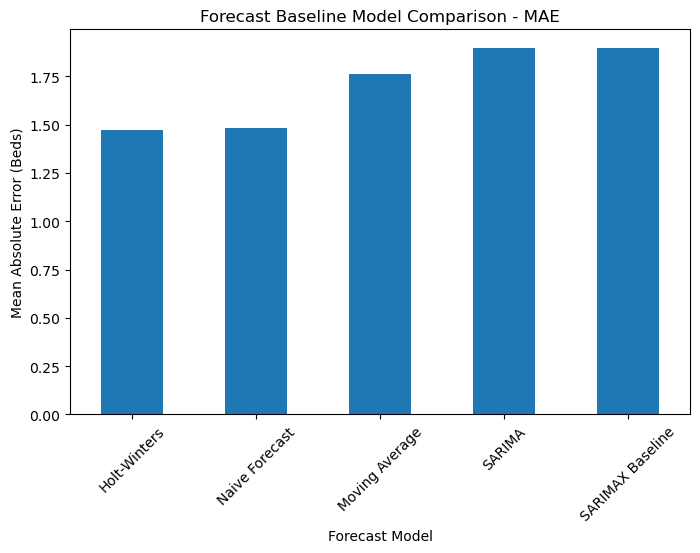

In [172]:
plt.figure(figsize=(8,5))
model_summary["MAE"].plot(kind="bar")
plt.title("Forecast Baseline Model Comparison - MAE")
plt.ylabel("Mean Absolute Error (Beds)")
plt.xlabel("Forecast Model")
plt.xticks(rotation=45)
plt.show()

    ### Overall Model Comparison Summary

    The comparison of all forecasting models shows that **Holt-Winters achieved the best overall performance**, with the lowest average MAE (**1.47**) and RMSE (**1.75**), indicating the most accurate predictions across hospital units. The **Naive Forecast model performed very similarly**, with slightly higher errors (MAE **1.48**, RMSE **1.76**), showing that recent demand patterns were strong predictors of future bed occupancy.
    The **Moving Average model** showed moderate performance but produced higher errors (MAE **1.76**, RMSE **2.03**), suggesting that smoothing historical demand reduced responsiveness to short-term changes.
    The **SARIMA and SARIMAX models recorded the highest overall errors** (MAE **1.90**, RMSE **2.14**), indicating that they were less effective across the full hospital network despite performing well for some individual wards with strong seasonal patterns.
    Overall, **Holt-Winters and Naive Forecast were the most reliable models for hospital bed demand forecasting**, while SARIMA/SARIMAX provided useful results for specific wards but struggled with highly variable demand patterns. The results suggest that simpler forecasting approaches may be sufficient for this dataset, with advanced models offering value mainly where strong seasonality or additional influencing factors exist.


Save the models

In [173]:
model_comparison.to_csv("../Models/Baseline Models/Results/baseline_model_comparison.csv", index=False)
naive_results.to_csv("../Models/Baseline Models/Results/naive_forecasts.csv", index=False)
moving_average_results.to_csv("../Models/Baseline Models/Results/moving_average_forecasts.csv", index=False)
holt_results.to_csv("../Models/Baseline Models/Results/holt_forecasts.csv", index=False)
sarima_results.to_csv("../Models/Baseline Models/Results/sarima_forecasts.csv", index=False)
sarimax_results.to_csv("../Models/Baseline Models/Results/sarimax_forecasts.csv", index=False)